In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import networkx as nx
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import itertools

In [3]:
filt_n1 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv").to_pandas()

In [4]:
n_random = 10
rand_ngc1 = {}
for i in range(n_random):
    rand_ngc1[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_1_random_{i}_filt.fits").to_pandas()

In [5]:
void = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_void.parquet"
        df = pd.read_parquet(file)
        void[j] = df

In [6]:
filament = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_filament.parquet"
        df = pd.read_parquet(file)
        filament[j] = df

In [7]:
filament[0]

,TARGETID,TARGETID_filament
0,39627546840534396,39627570437687054
1,39627546840534396,39627570399936731
2,39627546840534396,39627552800636997
3,39627546840534396,39627558760744666
4,39627546840534396,39627558764937716
...,...,...
2896437,39627829561787298,39627829565983475
2896438,39627829561787298,39627835605781687
2896439,39627829561787298,39627835609973255
2896440,39627829561787298,39627811442398323


In [8]:
knot = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_knot.parquet"
        df = pd.read_parquet(file)
        knot[j] = df

In [9]:
def alignment(df):
    if hasattr(df, 'to_pandas'):
        df = df.to_pandas()
    coords = df[['x', 'y', 'z']].values.astype(float)
    pca = PCA(n_components=3)
    coords_rotated = pca.fit_transform(coords)
    return coords_rotated

In [10]:
def new_coords(data):
    new_coords = alignment(data)
    data[['x_rot', 'y_rot', 'z_rot']] = new_coords

In [11]:
new_coords(filt_n1)
new_coords(rand_ngc1[0])

In [12]:
def network(data,group,string_group):
  filt_data = data[['TARGETID', 'x_rot', 'y_rot', 'z_rot']]

  G = nx.Graph()

  edges = zip(group['TARGETID'], group[f'TARGETID_{string_group}'])
  G.add_edges_from(edges)

  componentes = nx.connected_components(G)

  df_grupo_new = {}

  for grupo in componentes:
      grupo_ids = list(grupo)

      group_id = grupo_ids[0]

      df_grupo = filt_data[filt_data['TARGETID'].isin(grupo_ids)].copy()
      df_grupo['id'] = group_id

      df_grupo_new[group_id] = df_grupo

  return df_grupo_new,G

In [13]:
def groups(data,G):
  data_indexed = data.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo = [node for node in comp if node in data_indexed.index]
      if len(ids_en_grupo) == 0:
          continue
      df_grupo = data_indexed.loc[ids_en_grupo].copy().reset_index()
      groups[i] = df_grupo
  return groups

In [14]:
group_filament,G_filament = network(filt_n1,filament[0],'filament')
final_group_filament = groups(filt_n1,G_filament)

Groups: 3161


In [15]:
group_void,G_void = network(rand_ngc1[0],void[0],'void')
final_group_void = groups(rand_ngc1[0],G_void)

Groups: 1331


In [16]:
group_knot,G_knot = network(filt_n1,knot[0],'knot')
final_group_knot = groups(filt_n1,G_knot)

Groups: 1629


In [17]:
def plot_groups(groups, title):
  fig, ax = plt.subplots(figsize=(12, 10))

  #ax.scatter(filt_n1_df['x_rot'], filt_n1_df['y_rot'], c='k', s=0.5, label='Data')

  for i in groups:
      ax.scatter(groups[i]['x_rot'], groups[i]['y_rot'], s=5)

  ax.set_xlabel('PC1', fontsize=14)
  ax.set_ylabel('PC2', fontsize=14)
  ax.set_aspect('equal', adjustable='box')
  ax.grid(True, linestyle='--', linewidth=0.5)
  ax.set_title(f'Groups {title}', fontsize=15)

  plt.tight_layout()

  plt.show()

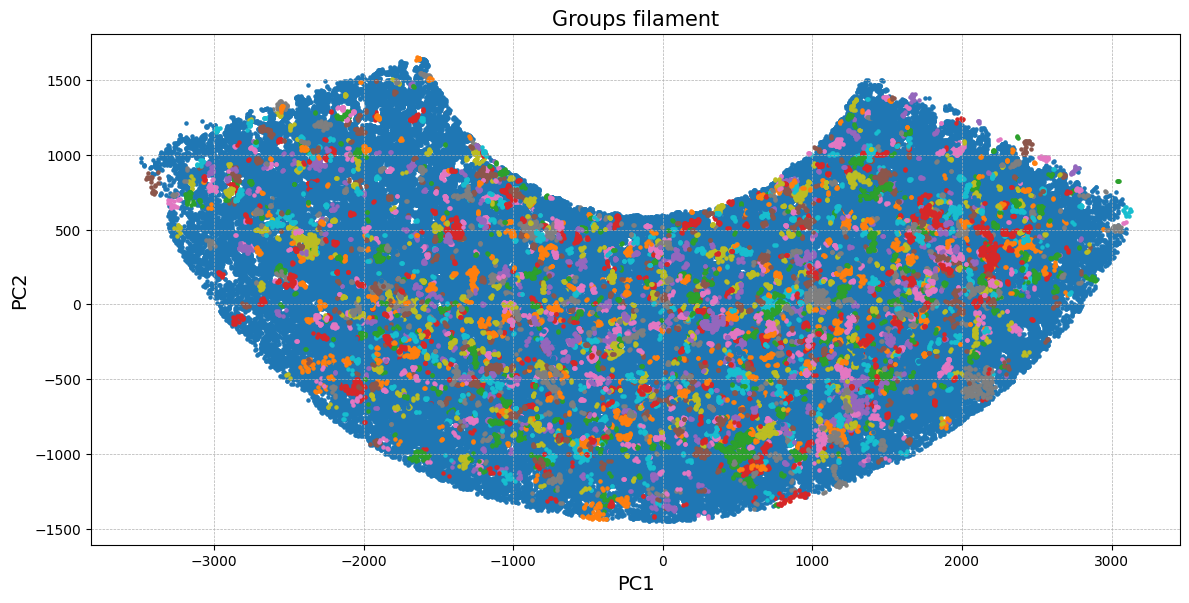

In [18]:
plot_groups(final_group_filament,'filament')

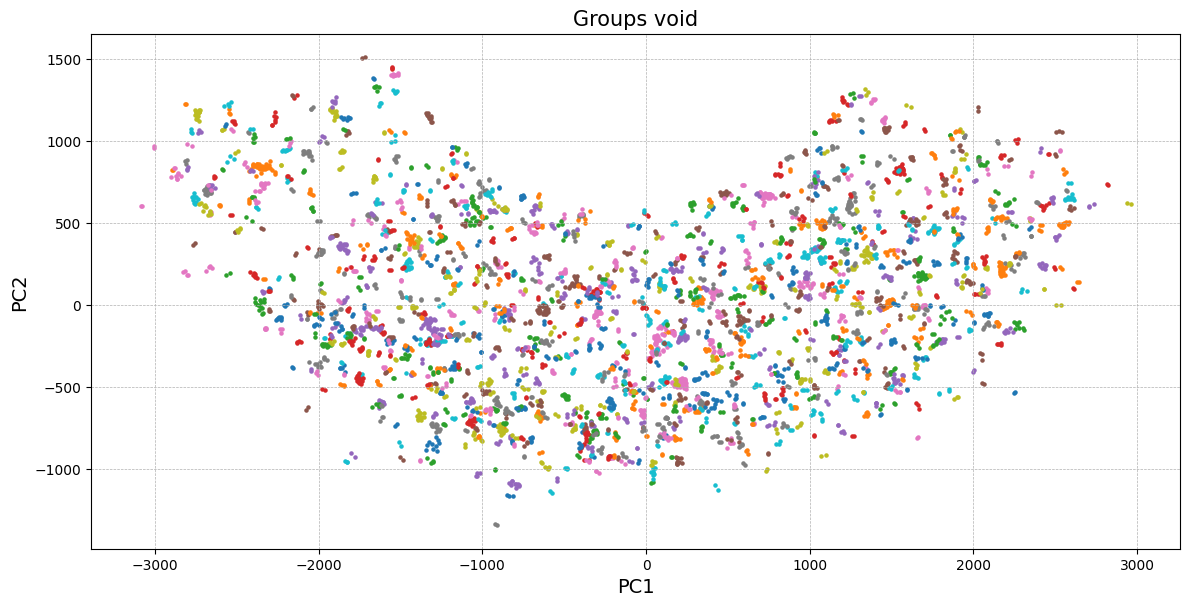

In [19]:
plot_groups(final_group_void,'void')

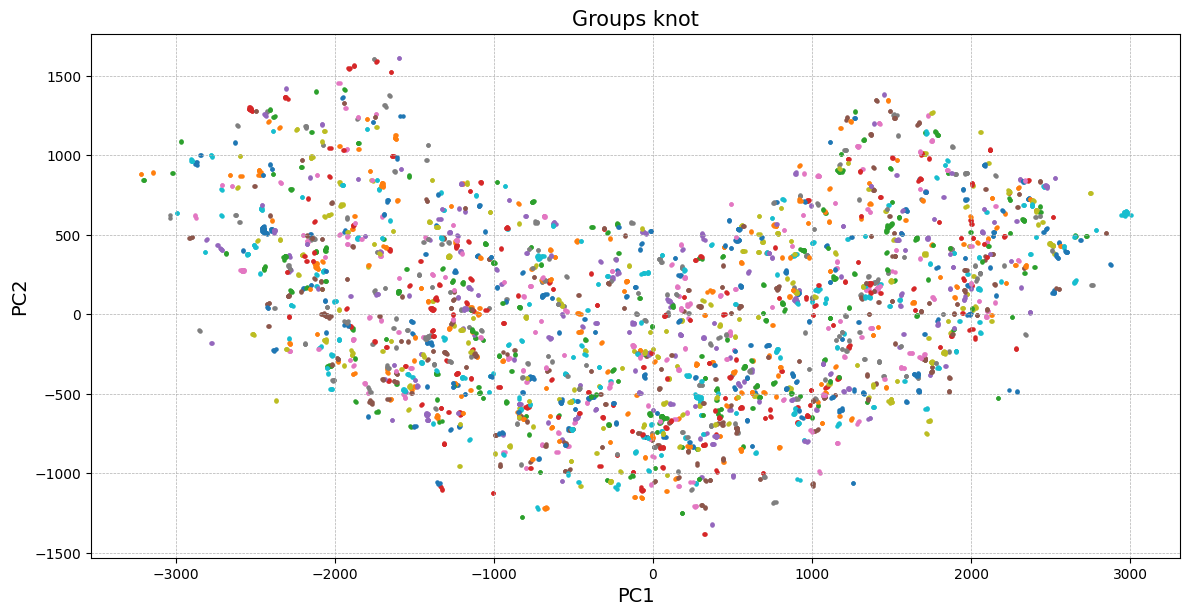

In [20]:
plot_groups(final_group_knot,'knot')

## Max neighbours

In [21]:
def network_max(data, group, string_group, max_neighbors=None, max_distance=None):
    filt_data = data[['TARGETID', 'x_rot', 'y_rot', 'z_rot']].copy()

    #merge coords
    group_coords = group.merge(filt_data, on='TARGETID', how='left') \
                        .rename(columns={'x_rot': 'x_src', 'y_rot': 'y_src', 'z_rot': 'z_src'})
    group_coords = group_coords.merge(
        filt_data,
        left_on=f'TARGETID_{string_group}',
        right_on='TARGETID',
        how='left',
        suffixes=('', '_dst')
    ).rename(columns={'x_rot': 'x_dst', 'y_rot': 'y_dst', 'z_rot': 'z_dst'})

    #distance
    group_coords['dist'] = np.sqrt(
        (group_coords['x_src'] - group_coords['x_dst'])**2 +
        (group_coords['y_src'] - group_coords['y_dst'])**2 +
        (group_coords['z_src'] - group_coords['z_dst'])**2
    )

    #max_distance
    if max_distance is not None:
        group_coords = group_coords[group_coords['dist'] <= max_distance]

    #max_neighbors
    if max_neighbors is not None:
        group_coords = (group_coords
                        .sort_values(['TARGETID', 'dist'])
                        .groupby('TARGETID', group_keys=False)
                        .head(max_neighbors))
    G = nx.Graph()
    G.add_edges_from(zip(group_coords['TARGETID'], group_coords[f'TARGETID_{string_group}']))

    componentes = list(nx.connected_components(G))
    print(f"Components: {len(componentes)} with max_neighbors={max_neighbors}, max_distance={max_distance}")

    df_grupo_new = {}
    for comp in componentes:
        ids = list(comp)
        gid = ids[0]
        df = filt_data[filt_data['TARGETID'].isin(ids)].copy()
        df['id'] = gid
        df_grupo_new[gid] = df

    return df_grupo_new, G

In [22]:
def plot_groups_max(groups, title, max_groups=20):
    fig, ax = plt.subplots(figsize=(10, 8))

    colors = itertools.cycle(plt.cm.tab20.colors)

    for idx, (group_id, df_grupo) in enumerate(groups.items()):
        if idx >= max_groups:
            break
        ax.scatter(
            df_grupo['x_rot'],
            df_grupo['y_rot'],
            s=5,
            color=next(colors),
        )

    ax.set_xlabel('PC1', fontsize=14)
    ax.set_ylabel('PC2', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(f'Groups {title} (First {max_groups})', fontsize=15)
    ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()

In [23]:
def plot_top_groups(groups, title, top_n=10):
    sorted_groups = sorted(groups.items(), key=lambda item: len(item[1]), reverse=True)
    top_groups = sorted_groups[:top_n]

    fig, ax = plt.subplots(figsize=(12, 10))
    colors = itertools.cycle(plt.cm.tab10.colors)

    for group_id, df_grupo in top_groups:
        ax.scatter(
            df_grupo['x_rot'],
            df_grupo['y_rot'],
            s=6,
            color=next(colors),
            label=f'Grupo {group_id} (n={len(df_grupo)})'
        )

    ax.set_xlabel('PC1', fontsize=14)
    ax.set_ylabel('PC2', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(f'Top {top_n} bigger sizes - {title}', fontsize=15)
    ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()

##max_neighbors = 20, max_distanc = 30

In [24]:
%%time
group_filament_max, G_filament_max = network_max(
    data=filt_n1,
    group=filament[0],
    string_group='filament',
    max_neighbors=20,
    max_distance=30
)

final_group_filament_max = groups(filt_n1,G_filament_max) #16725

Components: 5798 with max_neighbors=20, max_distance=30
Groups: 5798
CPU times: user 1min 47s, sys: 1.11 s, total: 1min 48s
Wall time: 1min 49s


In [25]:
componentes = list(nx.connected_components(G_filament_max))
sizes = [len(c) for c in componentes]
sizes.sort(reverse=True)
print("Top 10 sizes:", sizes[:10])

Top 10 sizes: [329385, 1536, 401, 323, 320, 282, 280, 276, 273, 252]


/tmp/ipython-input-22-3593208002.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)


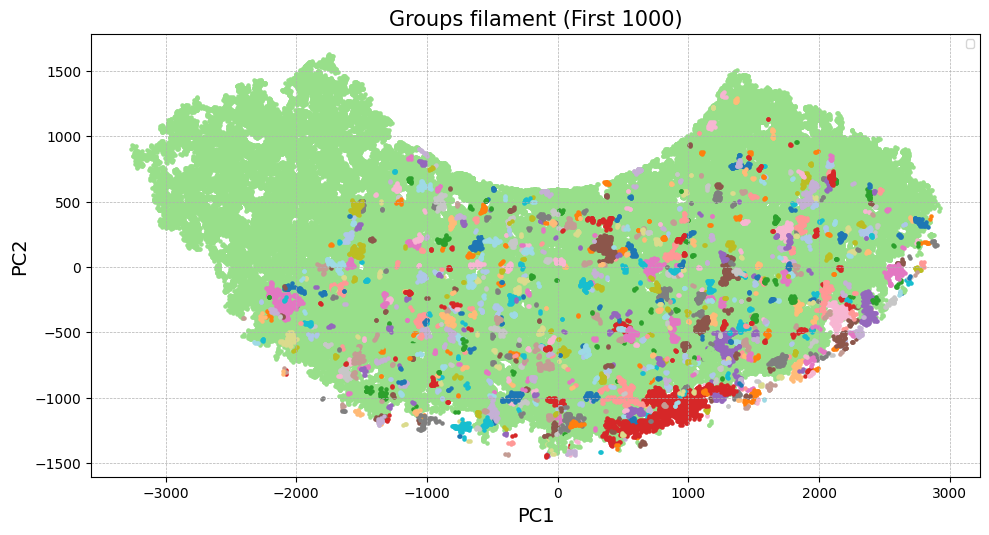

In [26]:
plot_groups_max(final_group_filament_max,'filament',max_groups=1000)

## max_neighbors = 20, max_distance = 20

In [27]:
%%time
group_filament_max, G_filament_max = network_max(
    data=filt_n1,
    group=filament[0],
    string_group='filament',
    max_neighbors=20,
    max_distance=21
)

final_group_filament_max = groups(filt_n1,G_filament_max)

Components: 14558 with max_neighbors=20, max_distance=21
Groups: 14558
CPU times: user 4min 10s, sys: 1.52 s, total: 4min 12s
Wall time: 4min 15s


In [28]:
componentes = list(nx.connected_components(G_filament_max))
sizes = [len(c) for c in componentes]
sizes.sort(reverse=True)
print("Top 10 sizes:", sizes[:10])

Top 10 sizes: [64707, 57840, 17224, 6585, 6226, 4538, 4530, 4412, 4181, 3068]


/tmp/ipython-input-22-3593208002.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)


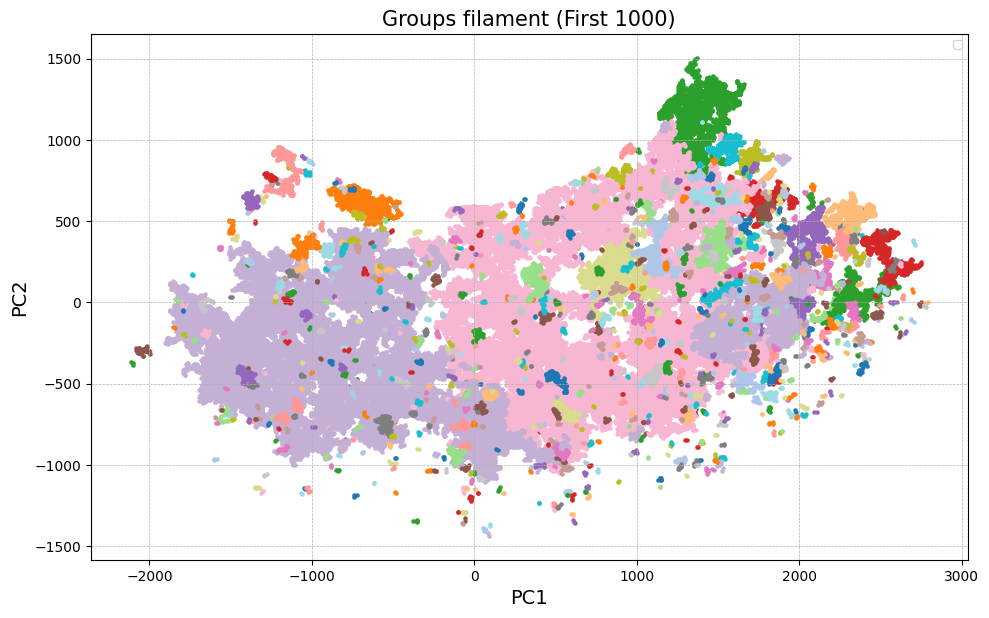

CPU times: user 11.1 s, sys: 124 ms, total: 11.2 s
Wall time: 11.3 s


In [29]:
%%time
plot_groups_max(final_group_filament_max,'filament',max_groups=1000)

/tmp/ipython-input-22-3593208002.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)


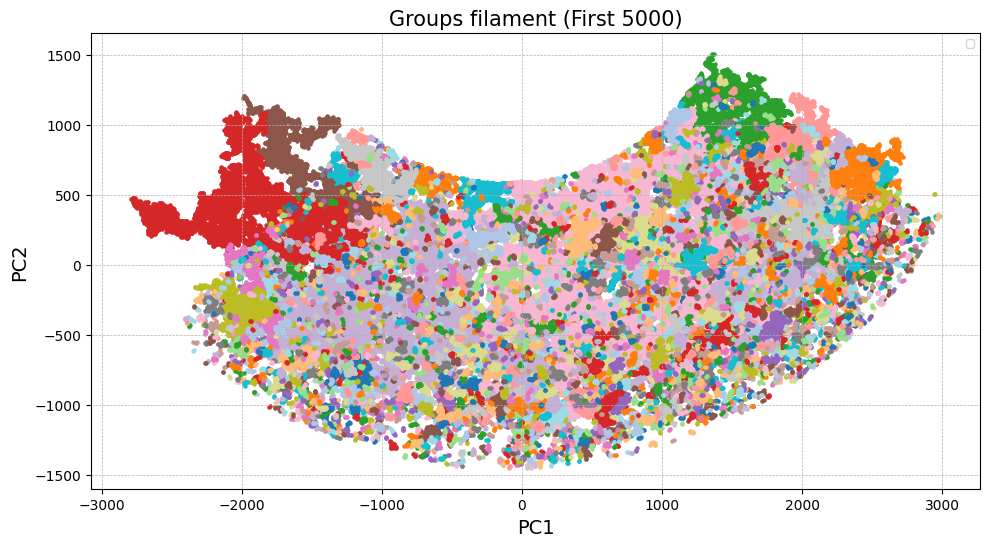

CPU times: user 1min 29s, sys: 585 ms, total: 1min 30s
Wall time: 1min 30s


In [30]:
%%time
plot_groups_max(final_group_filament_max,'filament',max_groups=5000)

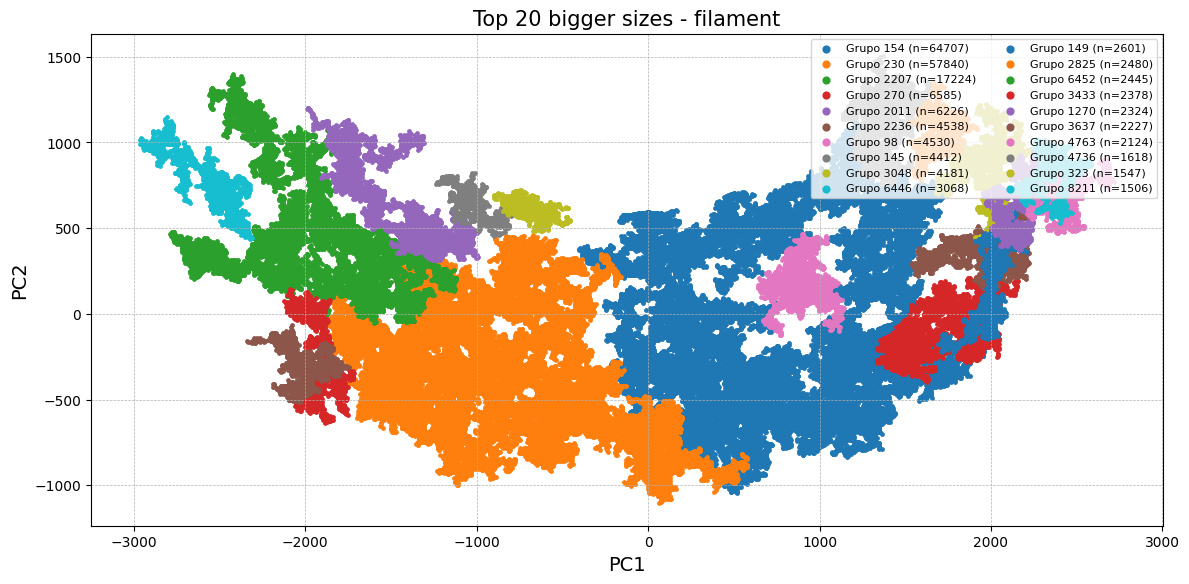

CPU times: user 889 ms, sys: 16 ms, total: 905 ms
Wall time: 908 ms


In [31]:
%%time
plot_top_groups(final_group_filament_max, title="filament", top_n=20)